# Baseline Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)
5. [Generalization](#generalization)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

RANDOM_STATE = 42

# Project root resolved relative to the working directory
# (robust: walks up from the cwd until it finds the repo's requirements.txt,
#  so the notebook runs regardless of where it is launched from)
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())
LANDMARKS_DIR = PROJECT_ROOT / "1_DatasetCharacteristics" / "landmarks" / "normalized"
DATA_PATH     = LANDMARKS_DIR / "landmarks_all_norm_10fps.csv"

## Model Choice

**DummyClassifier** (`most_frequent`) always predicts GOOD — the floor any real model must beat.

**RandomForestClassifier** as baseline: handles non-linearity and strongly correlated coordinates (left/right shoulder x ≈ 0.91) without feature engineering or scaling, `class_weight='balanced'` counters the 88/12 split, and feature importances are readable.

## Feature Selection

**Features:** the 66 normalized landmark coordinates (33 landmarks × x, y). Normalized, so the model cannot key on camera position or subject distance.
**Target:** `GOOD` (1 = correct, 0 = faulty). `BAD` is its complement and dropped; `phase` belongs to the other task.

### Stroke-aware Split

A random split would leak: a stroke spans ~27 correlated frames, so frame 100 in train and frame 101 in test describe the same motion. `GroupShuffleSplit` keeps each stroke on one side, using the real boundaries from the per-video `…-strokes.csv`. The 331 frames outside any stroke (`phase = 0`) are dropped.

In [2]:
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv(DATA_PATH)

feature_cols = [c for c in df.columns if c.endswith("_norm")]

# ── Group every frame by its stroke, using the real segment boundaries ──
# The combined CSV is the sorted concatenation of the per-video files, so the
# same sort order reproduces the frame offsets exactly.
stroke_id = np.full(len(df), -1, dtype=int)
video_of  = np.empty(len(df), dtype=object)
offset = next_id = 0

for f in sorted(LANDMARKS_DIR.glob("*-landmarks-norm_10fps.csv")):
    video    = f.name.replace("-landmarks-norm_10fps.csv", "")
    n_frames = len(pd.read_csv(f, usecols=["phase"]))
    video_of[offset:offset + n_frames] = video

    for _, s in pd.read_csv(LANDMARKS_DIR / f"{video}-strokes.csv").iterrows():
        stroke_id[offset + int(s.endzug_start):offset + int(s.endzug_end)] = next_id
        next_id += 1
    offset += n_frames

assert offset == len(df), "frame offsets do not add up"
# frames outside a stroke must be exactly the phase == 0 frames
assert ((stroke_id == -1) == (df["phase"] == 0).values).all()

# ── Drop frames that belong to no stroke ────────────────────────────
keep = stroke_id != -1
X, y   = df.loc[keep, feature_cols].values, df.loc[keep, "GOOD"].values
groups = stroke_id[keep]
videos = video_of[keep]

print(f"Frames:   {len(df)}  ->  {len(y)} in strokes  ({(~keep).sum()} outside)")
print(f"Features: {X.shape[1]}")
print(f"Strokes:  {len(np.unique(groups))}")
print(f"GOOD frames: {y.sum()} ({y.mean()*100:.1f}%)  |  BAD frames: {(1-y).sum()} ({(1-y).mean()*100:.1f}%)")

# ── Stroke-aware split ──────────────────────────────────────────────
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

assert not set(groups[train_idx]) & set(groups[test_idx]), "stroke leaked across the split"
print(f"\nTrain: {len(train_idx)} frames  |  GOOD: {y_train.mean()*100:.1f}%")
print(f"Test:  {len(test_idx)} frames  |  GOOD: {y_test.mean()*100:.1f}%")

Frames:   18139  ->  17808 in strokes  (331 outside)
Features: 66
Strokes:  657
GOOD frames: 15756 (88.5%)  |  BAD frames: 2052 (11.5%)

Train: 14240 frames  |  GOOD: 89.7%
Test:  3568 frames  |  GOOD: 83.6%


## Implementation

Both models are trained on the same 80 % split and evaluated on the held-out 20 %.

In [3]:
# --- DummyClassifier (always predicts majority class = GOOD) ---
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

# --- Random Forest with balanced class weights ---
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


## Evaluation

| Metric | Why it matters |
|--------|----------------|
| **Accuracy** | Misleading at 88/12 imbalance; shown for completeness |
| **Macro F1** | Weights both classes equally |
| **ROC-AUC** | Threshold-independent ranking quality |
| **Recall (BAD)** | The costly error is missing a bad stroke |


  DummyClassifier (majority baseline)
  Accuracy :  0.8360
  ROC-AUC  :  0.5000
  Macro F1 :  0.4554

  Classification Report:
              precision    recall  f1-score   support

         BAD       0.00      0.00      0.00       585
        GOOD       0.84      1.00      0.91      2983

    accuracy                           0.84      3568
   macro avg       0.42      0.50      0.46      3568
weighted avg       0.70      0.84      0.76      3568


  Random Forest (baseline model)
  Accuracy :  0.9812
  ROC-AUC  :  0.9979
  Macro F1 :  0.9648

  Classification Report:
              precision    recall  f1-score   support

         BAD       0.97      0.91      0.94       585
        GOOD       0.98      1.00      0.99      2983

    accuracy                           0.98      3568
   macro avg       0.98      0.95      0.96      3568
weighted avg       0.98      0.98      0.98      3568



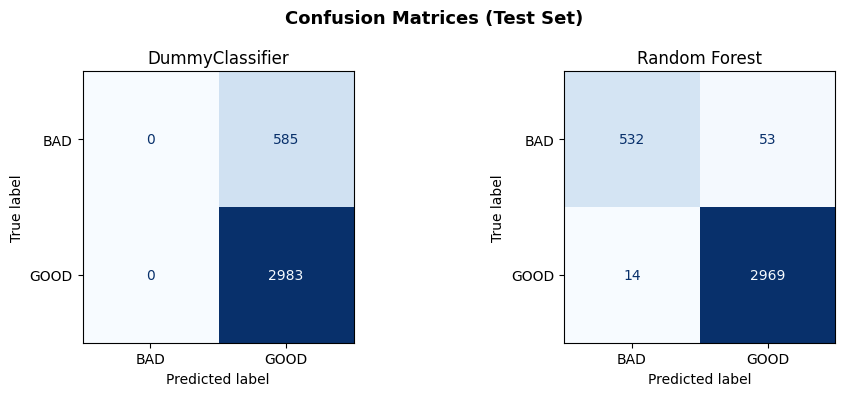

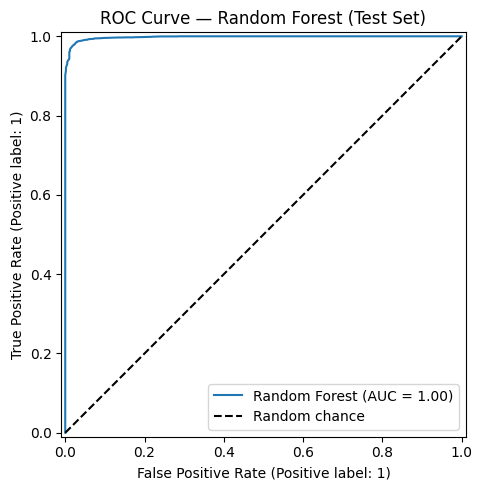

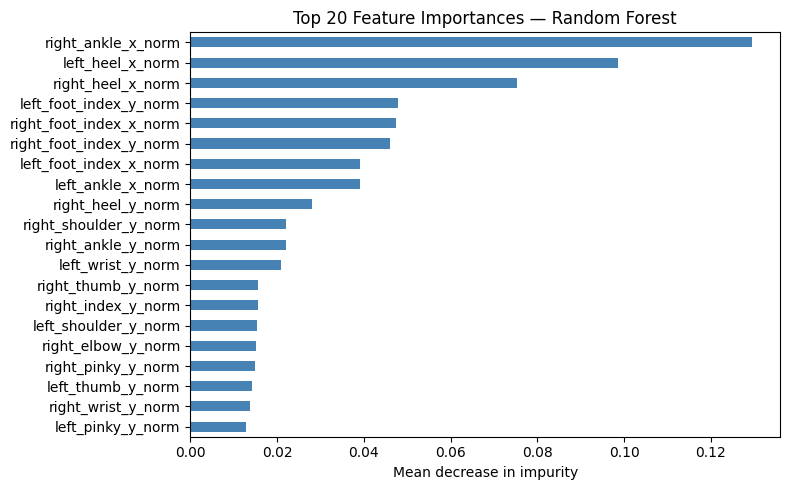

In [4]:
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["BAD", "GOOD"], output_dict=True, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else float("nan")

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy :  {acc:.4f}")
    print(f"  ROC-AUC  :  {auc:.4f}")
    print(f"  Macro F1 :  {report['macro avg']['f1-score']:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["BAD", "GOOD"], zero_division=0))

    return y_pred, y_proba

y_pred_dummy, y_proba_dummy = evaluate(dummy, X_test, y_test, "DummyClassifier (majority baseline)")
y_pred_rf,    y_proba_rf    = evaluate(rf,    X_test, y_test, "Random Forest (baseline model)")

# ── Confusion matrices ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_pred, title in zip(
    axes,
    [y_pred_dummy, y_pred_rf],
    ["DummyClassifier", "Random Forest"]
):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=["BAD", "GOOD"]
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
plt.suptitle("Confusion Matrices (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── ROC Curve (Random Forest only) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random chance")
ax.set_title("ROC Curve — Random Forest (Test Set)")
ax.legend()
plt.tight_layout()
plt.show()

# ── Feature importances (top 20) ────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
importances.head(20).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 Feature Importances — Random Forest")
ax.set_xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

## Generalization

Whole strokes stay together in the split above, but strokes of the *same video* still appear on both sides. Since both BAD recordings come from one rower, the model may be recognising the recording rather than the technique.

Stricter check: hold out one entire video, train on the other ten. Each video carries a single label, so the score is the share of frames labelled correctly.

In [5]:
# ── Leave-one-video-out ─────────────────────────────────────────────
rows = []
for video in sorted(set(videos)):
    te = videos == video
    m  = RandomForestClassifier(
        n_estimators=100, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ).fit(X[~te], y[~te])

    truth = y[te][0]                      # each video carries a single label
    rows.append({
        "video":     video,
        "label":     "GOOD" if truth == 1 else "BAD",
        "frames":    int(te.sum()),
        "correct_%": round((m.predict(X[te]) == truth).mean() * 100, 1),
    })

df_lovo = pd.DataFrame(rows)
print(df_lovo.to_string(index=False))
print(f"\nGOOD videos: {df_lovo[df_lovo.label == 'GOOD']['correct_%'].mean():.1f} % correct on average")
print(f"BAD  videos: {df_lovo[df_lovo.label == 'BAD']['correct_%'].mean():.1f} % correct on average")

                        video label  frames  correct_%
                      cla-BAD   BAD     477        5.5
                    cla-BAD-2   BAD    1575        5.3
                cla-GOOD-fast  GOOD    2068       89.7
                cla-GOOD-slow  GOOD    1882       90.1
              cla-GOOD-slow-2  GOOD     789        0.1
man-GOOD-slow-MIRRORED-7.5min  GOOD    4413       99.8
                mar-GOOD-fast  GOOD    1381       98.8
                mar-GOOD-slow  GOOD    1342       96.6
                sim-GOOD-fast  GOOD    1142      100.0
                sim-GOOD-slow  GOOD    2414      100.0
               sim-GOOD-slow2  GOOD     325      100.0

GOOD videos: 86.1 % correct on average
BAD  videos: 5.4 % correct on average


### What do the features actually encode?

If the label is predictable from *who* is in the frame, the model never has to learn technique. Same features, same forest — but predicting the rower and the recording instead of GOOD/BAD.

In [6]:
# ── Identity probe: how much of the rower is in the features? ───────
person = np.array([v.split("-")[0] for v in videos])

for target, name in [(person, "rower"), (videos, "recording")]:
    n_classes = len(set(target))
    tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
                  .split(X, target, groups=groups))
    m = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X[tr], target[tr])
    acc = (m.predict(X[te]) == target[te]).mean()
    print(f"Identify the {name:<10} ({n_classes:2d} classes): {acc*100:5.1f} %   (chance {100/n_classes:4.1f} %)")

Identify the rower      ( 4 classes):  99.6 %   (chance 25.0 %)


Identify the recording  (11 classes):  96.6 %   (chance  9.1 %)


## Summary & Next Steps

| Model | Accuracy | ROC-AUC | Macro F1 | Recall (BAD) |
|-------|---------|---------|----------|--------------|
| DummyClassifier | 0.836 | 0.500 | 0.455 | 0.00 |
| Random Forest | 0.981 | 0.998 | 0.965 | 0.91 |

Leave-one-video-out: GOOD videos 86.1 % correct, **BAD videos 5.4 %**.

### The model learns people, not rowing

The same 66 features identify the rower to 99.6 % and the recording to 96.6 %. Normalization removes the camera, not body proportions — every rower is identifiable.

All BAD frames come from `cla-BAD` and `cla-BAD-2`, and strokes of those two recordings sit on both sides of the split. So one rule — *looks like those two → BAD* — already gives 0.98 accuracy, with no notion of technique. Any classifier would find this shortcut; it is the easiest signal and matches the label perfectly.

Remove it and nothing remains: on a BAD recording it never trained on, the model marks ~5 % of frames as BAD. Held-out `cla-GOOD-slow-2` shows the same from the other side — it is called BAD, because `cla` is over-represented among BAD frames in the remaining training data.

Cross-validation misses this: grouping by stroke asks *"more strokes from a recording I know?"*, never *"a new rower?"*. The ±0.003 across folds is not robustness — all five folds share the same shortcut.

The cause is the **data**, not the model. With BAD from one rower, "faulty technique" and "this person" are inseparable; an LSTM would not help.

### Next Steps

- **BAD recordings from more rowers** — the prerequisite for everything else
- Report leave-one-video-out, not just the random split
- Temporal / delta features; the movement signal lies in direction, not position
- Per-stroke aggregation instead of per-frame classification
- LSTM or 1D-CNN for the stroke sequence